In [143]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")


In [144]:
from dotenv import load_dotenv
import os
import pandas as pd
from pathlib import Path
# google.colab.drive is only imported if IN_COLAB is True

# --- Configuration for Dataset Folder ---
# Check if running in Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # In Colab, default to /content/ for data storage
    DATASET_FOLDER = os.getenv("DATASET_FOLDER", "/content/")
else:
    # Outside Colab, default to a local 'data' directory in the current working directory
    # Users can set the DATASET_FOLDER environment variable or modify the .env file to change this.
    DATASET_FOLDER = os.getenv("DATASET_FOLDER", "./data/")

dataset_path = Path(DATASET_FOLDER)

# --- Mount Google Drive and Download Files (Colab only) ---
if IN_COLAB:
    from google.colab import drive # Import drive only if in Colab
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

    # Install gdown if not already installed
    try:
        import gdown
    except ImportError:
        print("gdown not found. Installing gdown...")
        !pip install gdown -q
        import gdown

    # Google Drive folder ID (extracted from the provided URL)
    # URL: https://drive.google.com/drive/folders/1PmLapJI1VSDgvl_AxARNKwM1MCd3WFX0
    GOOGLE_DRIVE_FOLDER_ID = '1PmLapJI1VSDgvl_AxARNKwM1MCd3WFX0'

    # Download contents of the Google Drive folder to the specified dataset folder
    print(f"\nDownloading files from Google Drive folder ID: {GOOGLE_DRIVE_FOLDER_ID} to {DATASET_FOLDER}")

    # Ensure the target directory exists before downloading
    dataset_path.mkdir(parents=True, exist_ok=True)

    # Use gdown to download all files from the folder to the target directory
    # For folder IDs, gdown downloads contents into the current working directory.
    # We ensure the current working directory is the DATASET_FOLDER before downloading.
    current_cwd = os.getcwd()
    os.chdir(DATASET_FOLDER) # Change to the dataset folder
    !gdown --id $GOOGLE_DRIVE_FOLDER_ID --fuzzy --no-check-certificate
    os.chdir(current_cwd) # Change back to original working directory
    print(f"Files downloaded successfully to {DATASET_FOLDER}")
else:
    print(f"Not in Google Colab environment. Skipping Google Drive mount and gdown download.")
    print(f"Expecting dataset files to be located in: {DATASET_FOLDER}")

# Ensure the dataset directory exists (for both Colab and local environments)
if not dataset_path.exists():
    dataset_path.mkdir(parents=True, exist_ok=True)
    print(f"Created directory: {dataset_path}")
else:
    print(f"Directory already exists: {dataset_path}")

# Create a sample .env file for demonstration purposes
env_content = f"""
# --- Dataset File Paths ---
# This DATASET_FOLDER variable determines where the data files are expected to be.
# If running outside Colab, you can change this to your local data directory.
# Example: DATASET_FOLDER=./my_local_data_folder/
# The paths below will automatically adjust based on DATASET_FOLDER.

DATASET_FOLDER={DATASET_FOLDER}
CUSTOMERS_FILE={DATASET_FOLDER}customers.csv
ORDERS_FILE={DATASET_FOLDER}orders.csv
WEB_FILE={DATASET_FOLDER}web_events_snapshot.csv
LABELS_FILE={DATASET_FOLDER}churn_labels.csv
INTERVENTIONS_FILE={DATASET_FOLDER}intervention_history.csv
TICKETS_FILE={DATASET_FOLDER}support_tickets.csv
"""

with open(".env", "w") as f:
    f.write(env_content)

print("A sample .env file has been created/updated in the current directory.")
print("Content of .env file:\n" + env_content)

# Load .env file
load_dotenv()

# Base path for fallback (now dynamic based on environment)
base_path = dataset_path

# Define file paths, prioritizing environment variables, then the determined base_path
customers_path = os.getenv("CUSTOMERS_FILE", str(base_path / "customers.csv"))
orders_path = os.getenv("ORDERS_FILE", str(base_path / "orders.csv"))
web_path = os.getenv("WEB_FILE", str(base_path / "web_events_snapshot.csv"))
labels_path = os.getenv("LABELS_FILE", str(base_path / "churn_labels.csv"))
interventions_path = os.getenv("INTERVENTIONS_FILE", str(base_path / "intervention_history.csv"))
tickets_path = os.getenv("TICKETS_FILE", str(base_path / "support_tickets.csv"))

print("\nUsing paths:")
print(f"  Customers: {customers_path}")
print(f"  Orders: {orders_path}")
print(f"  Web: {web_path}")
print(f"  Labels: {labels_path}")
print(f"  Interventions: {interventions_path}")
print(f"  Tickets: {tickets_path}")


# Load datasets with error handling for FileNotFoundError
try:
    customers = pd.read_csv(customers_path)
    orders = pd.read_csv(orders_path)
    web = pd.read_csv(web_path)
    labels = pd.read_csv(labels_path)
    interventions = pd.read_csv(interventions_path)
    tickets = pd.read_csv(tickets_path)

    datasets = {
        'customers': customers,
        'orders': orders,
        'web': web,
        'labels': labels,
        'interventions': interventions,
        'tickets': tickets
    }

    for name, df in datasets.items():
        print('\n', '='*40)
        print(name.upper())
        print(df.info())
        print(df.describe(include='all'))

except FileNotFoundError as e:
    print(f"\nError loading dataset: {e}")
    print(f"Please ensure the data files are present in the specified directory: {DATASET_FOLDER}")
    if not IN_COLAB:
        print(f"If running outside Colab, you might need to manually place the files in {DATASET_FOLDER} or update the DATASET_FOLDER variable in your .env file or directly in the script.")
except Exception as e:
    print(f"\nAn unexpected error occurred during data loading: {e}")

Not in Google Colab environment. Skipping Google Drive mount and gdown download.
Expecting dataset files to be located in: ./data/
Directory already exists: data
A sample .env file has been created/updated in the current directory.
Content of .env file:

# --- Dataset File Paths ---
# This DATASET_FOLDER variable determines where the data files are expected to be.
# If running outside Colab, you can change this to your local data directory.
# Example: DATASET_FOLDER=./my_local_data_folder/
# The paths below will automatically adjust based on DATASET_FOLDER.

DATASET_FOLDER=./data/
CUSTOMERS_FILE=./data/customers.csv
ORDERS_FILE=./data/orders.csv
WEB_FILE=./data/web_events_snapshot.csv
LABELS_FILE=./data/churn_labels.csv
INTERVENTIONS_FILE=./data/intervention_history.csv
TICKETS_FILE=./data/support_tickets.csv


Using paths:
  Customers: ./data/customers.csv
  Orders: ./data/orders.csv
  Web: ./data/web_events_snapshot.csv
  Labels: ./data/churn_labels.csv
  Interventions: ./data/interv

Data can be imported and saved in local at runtime.Code is made to work with Colab to dowbload data in content folder automatically or manually place csv file in data folder when running in local environment.Using dvc pipeline is not mandatory as per requirement, so manual data movement into project data folder is suggested, to keep data out of github environment.

Chart saved to: e:\d2c-churn-eda\charts\churn_distribution_bar.png


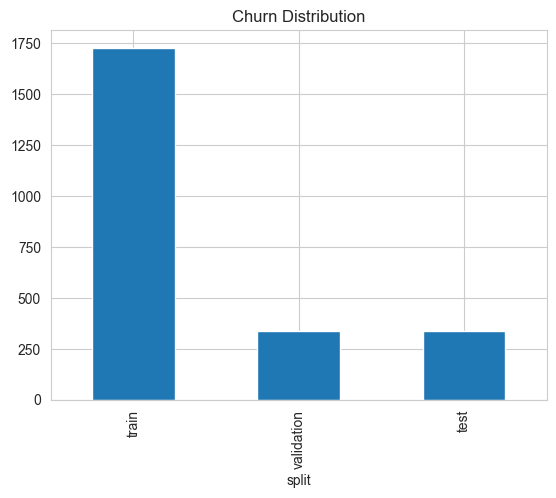

Chart saved to: e:\d2c-churn-eda\charts\top_ticket_categories_bar.png


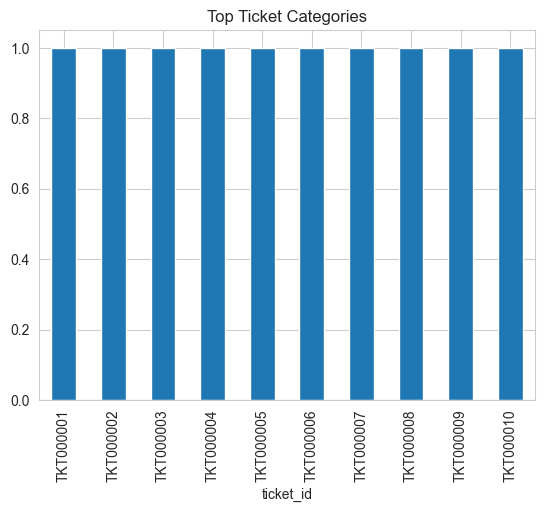

Chart saved to: e:\d2c-churn-eda\charts\top_web_events_bar.png


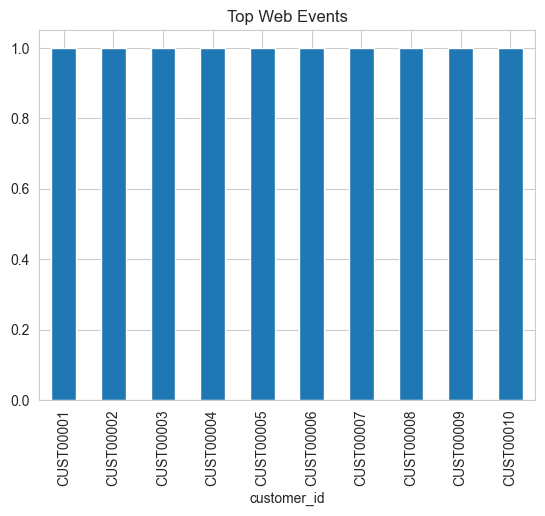

In [145]:
labels.iloc[:, -1].value_counts().plot(kind='bar', title='Churn Distribution')
save_chart('churn_distribution_bar.png')
plt.show()

plt.figure() # Create a new figure for the next plot
tickets.iloc[:,0].astype(str).value_counts().head(10).plot(kind='bar', title='Top Ticket Categories')
save_chart('top_ticket_categories_bar.png')
plt.show()

plt.figure() # Create a new figure for the next plot
web.iloc[:,0].astype(str).value_counts().head(10).plot(kind='bar', title='Top Web Events')
save_chart('top_web_events_bar.png')
plt.show()

Chart saved to: e:\d2c-churn-eda\charts\missing_value_percentage.png


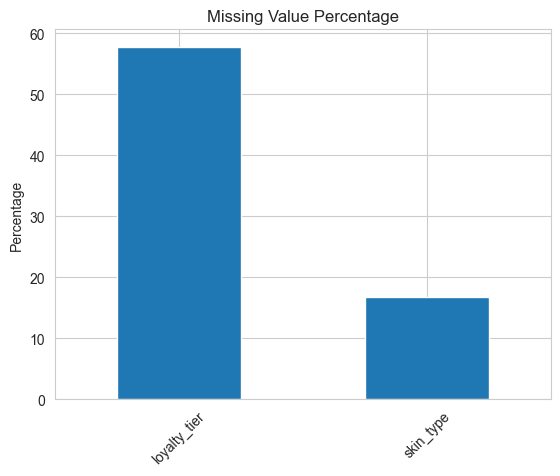

In [146]:
missing = customers.isnull().mean().sort_values(ascending=False) * 100

missing = missing[missing > 0]

missing.plot(kind='bar')

plt.title("Missing Value Percentage")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
save_chart('missing_value_percentage.png')
plt.show()

In [147]:
duplicates = customers.duplicated().sum()

print(f"Duplicate Records: {duplicates}")

Duplicate Records: 0


   churn_flag  customer_count  percentage    status
0           0            1273       53.04  Retained
1           1            1127       46.96   Churned
Chart saved to: e:\d2c-churn-eda\charts\customer_distribution_by_churn_status.png


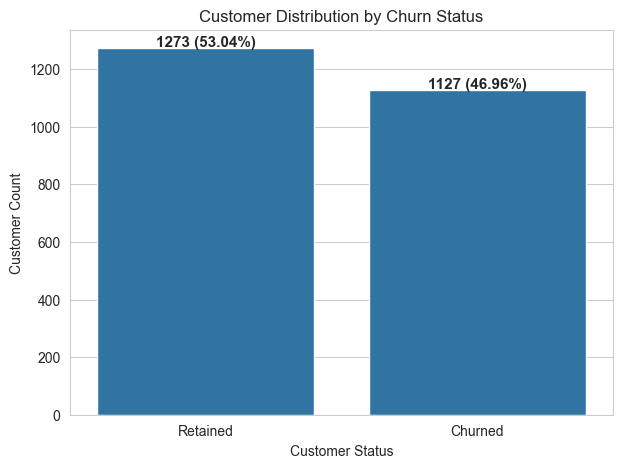

In [148]:
# ==========================================
# Churn Distribution with Percentage Labels
# ==========================================

# Count customers
churn_summary = (
    labels['churn_next_60d']
    .value_counts()
    .reset_index()
)

# Rename columns
churn_summary.columns = ['churn_flag', 'customer_count']

# Calculate percentage
total = churn_summary['customer_count'].sum()

churn_summary['percentage'] = (
    churn_summary['customer_count'] / total * 100
).round(2)

# Optional readable labels
churn_summary['status'] = churn_summary['churn_flag'].map({
    0: 'Retained',
    1: 'Churned'
})

print(churn_summary)

# ==========================================
# Visualization
# ==========================================

plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=churn_summary,
    x='status',
    y='customer_count'
)

# Add count + percentage labels
for i, row in churn_summary.iterrows():

    ax.text(
        i,
        row['customer_count'] + 5,
        f"{row['customer_count']} ({row['percentage']}%)",
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.title("Customer Distribution by Churn Status")

plt.xlabel("Customer Status")
plt.ylabel("Customer Count")
save_chart('customer_distribution_by_churn_status.png')
plt.show()

Churn Risk Hypothesis 1: With all the due efforts taken till date Retained customer count is little above churned, indicative of need of better strategy for rententions to reduce churning of customers to miminum.

Chart saved to: e:\d2c-churn-eda\charts\customer_age_group_vs_churn.png


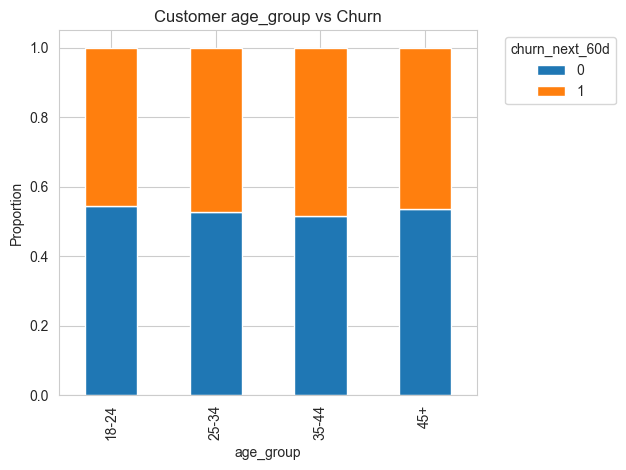

In [149]:


# choose an available segment column (fallbacks included) and ensure churn flag exists
seg_col = next((c for c in ['customer_segment', 'age_group', 'loyalty_tier', 'city_tier'] if c in customers.columns), None)
if seg_col is None:
    raise KeyError("No suitable segment column found in customers (checked customer_segment, age_group, loyalty_tier, city_tier)")

churn_col = 'churn_next_60d' if 'churn_next_60d' in labels.columns else ('churn_flag' if 'churn_flag' in labels.columns else None)
if churn_col is None:
    raise KeyError("No churn column found in labels (expected churn_next_60d or churn_flag)")

segment_churn = pd.crosstab(
    customers[seg_col],
    labels[churn_col],
    normalize='index'
)

segment_churn.plot(kind='bar', stacked=True)

plt.title(f"Customer {seg_col} vs Churn")
plt.ylabel("Proportion")
plt.xlabel(seg_col)
plt.legend(title=churn_col, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
save_chart(f'customer_{seg_col}_vs_churn.png')
plt.show()

Churn RIsk Hypothesis 2: Customer churned are well distributed among all age groups for 46% overall.Retention strategy for customers falling in different age groups is required evenly.

Chart saved to: e:\d2c-churn-eda\charts\order_frequency_distribution.png


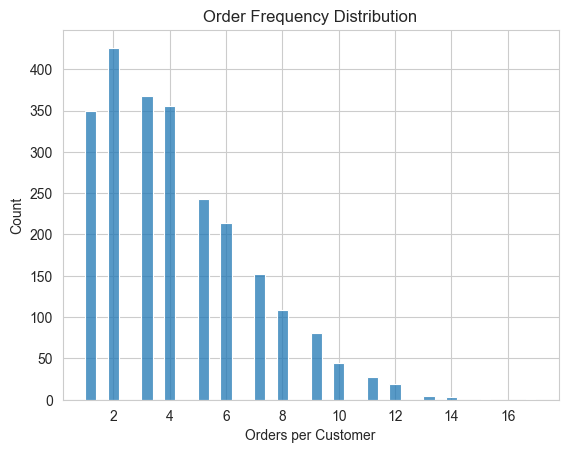

In [150]:
order_freq = (
    orders.groupby('customer_id')
    .size()
)

sns.histplot(order_freq, bins=40)

plt.title("Order Frequency Distribution")
plt.xlabel("Orders per Customer")
save_chart('order_frequency_distribution.png')
plt.show()

Chart saved to: e:\d2c-churn-eda\charts\order_value_distribution.png


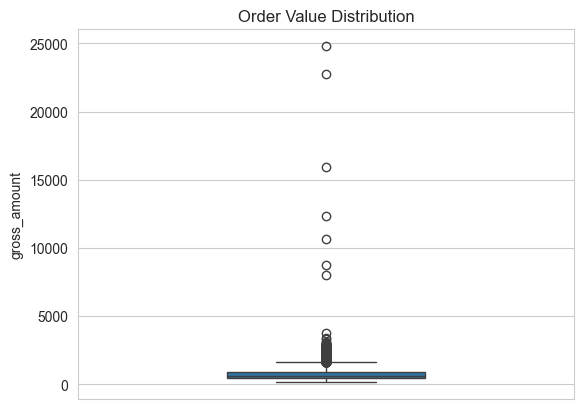

In [151]:
# Ensure orders DataFrame is available.
# It's assumed 'base_path' is already defined from previous cells (e.g., cell 13928e90).
import pandas as pd

if 'orders' not in globals():
    try:
        orders = pd.read_csv(base_path / "orders.csv")
    except FileNotFoundError:
        print("Error: 'orders.csv' not found. Please upload it to /content or ensure correct path.")
        raise # Re-raise if file is critical for this cell

# Determine the column for order value, prioritizing 'gross_amount' as seen in other related cells.
order_value_column = None
if 'gross_amount' in orders.columns:
    order_value_column = 'gross_amount'
elif 'order_value' in orders.columns:
    order_value_column = 'order_value'
else:
    raise KeyError("Neither 'gross_amount' nor 'order_value' column found in the 'orders' DataFrame for plotting order value distribution.")


sns.boxplot(
    data=orders,
    y=order_value_column,
    width=0.4,          # thinner box -> more visual spacing
    showfliers=True,    # show outliers
    whis=1.5            # whisker range
)

plt.title("Order Value Distribution")
save_chart('order_value_distribution.png')
plt.show()

Churn Risk Hypothesis 3 :
The analysis shows that churn is concentrated among customers who placed three or fewer orders. Customers with higher purchase frequency appear to be retained more consistently.

This suggests that:

many customers fail to transition from early-stage buyers into loyal repeat customers,
the highest churn risk occurs during the initial purchase lifecycle,
repeat purchasing is a strong indicator of customer engagement and retention.

Chart saved to: e:\d2c-churn-eda\charts\refund_rate_vs_churn.png


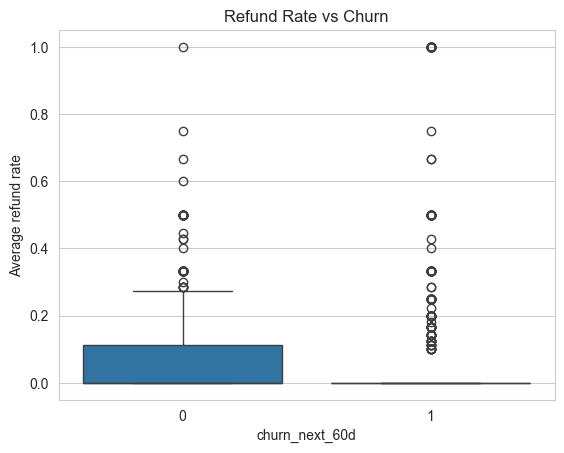

In [152]:
try:
    plt
except NameError:
    import matplotlib.pyplot as plt

orders_refund = orders.copy()

if 'is_refunded' not in orders_refund.columns:
    if 'returned' in orders_refund.columns:
        orders_refund['is_refunded'] = (orders_refund['returned'] > 0).astype(int)
    else:
        raise KeyError("No refund indicator found in orders; expected 'is_refunded' or 'returned'")

refund_rate = (
    orders_refund.groupby('customer_id')['is_refunded']
    .mean()
    .reset_index()
)

refund_rate = refund_rate.merge(
    labels[['customer_id', 'churn_next_60d']], # Changed churn_labels to labels and churn_flag to churn_next_60d
    on='customer_id',
    how='inner'
)

sns.boxplot(
    data=refund_rate,
    x='churn_next_60d', # Changed churn_flag to churn_next_60d
    y='is_refunded'
)

plt.title("Refund Rate vs Churn")
plt.ylabel("Average refund rate")
save_chart('refund_rate_vs_churn.png')
plt.show()

Churn-Risk Hypotheses -4
1. Customers with High Support Ticket Volume Are More Likely to Churn
Average support tickets by churn status

Churned customers show substantially higher support-ticket volume as visible above.
As per above plots:

Customers who churn (churn_flag = 1) tend to create fewer support tickets compared to retained customers (churn_flag = 0).




   churn_next_60d      mean  median  count
0               0  6.445058     0.0   1273
1               1  8.236123     0.0   1127
Chart saved to: e:\d2c-churn-eda\charts\refund_rate_vs_churn.png


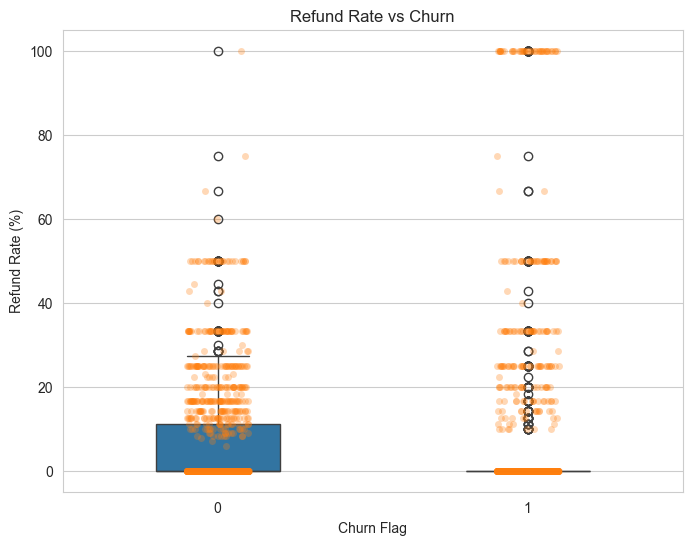

In [153]:
# Refund Rate vs Churn Analysis

# Step 1: Calculate refund rate per customer
orders_source = orders_refund if 'orders_refund' in globals() else orders.copy()

if 'is_refunded' not in orders_source.columns:
    if 'returned' in orders_source.columns:
        orders_source['is_refunded'] = (orders_source['returned'] > 0).astype(int)
    else:
        raise KeyError("No refund indicator found in orders; expected 'is_refunded' or 'returned'")

refund_rate = (
    orders_source.groupby('customer_id')['is_refunded']
    .mean()
    .reset_index()
)

# Rename column for clarity
refund_rate.rename(
    columns={'is_refunded': 'refund_rate'},
    inplace=True
)

# Convert to percentage
refund_rate['refund_rate'] = (
    refund_rate['refund_rate'] * 100
)

# Step 2: Merge with churn labels
refund_churn = refund_rate.merge(
    labels,
    on='customer_id',
    how='inner'
)

# Step 3: Summary table
summary_table = (
    refund_churn.groupby('churn_next_60d')['refund_rate']
    .agg(['mean', 'median', 'count'])
    .reset_index()
)

print(summary_table)

# Step 4: Visualization
plt.figure(figsize=(8,6))

sns.boxplot(
    data=refund_churn,
    x='churn_next_60d',
    y='refund_rate',
    width=0.4
)

sns.stripplot(
    data=refund_churn,
    x='churn_next_60d',
    y='refund_rate',
    alpha=0.3,
    jitter=True
)

plt.title("Refund Rate vs Churn")
plt.xlabel("Churn Flag")
plt.ylabel("Refund Rate (%)")
save_chart('refund_rate_vs_churn.png')
plt.show()

Refund Strategy: Refund rate percent averaging close to 10% indicates successful retention strategy.

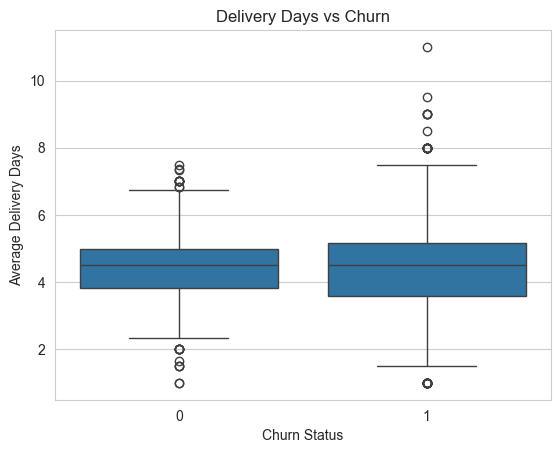

In [154]:
# Updated to use 'labels' DataFrame and 'churn_next_60d' consistently


if 'delivery_days' in orders.columns:
    delay_churn = (
        orders.groupby('customer_id')['delivery_days']
        .mean()
        .reset_index()
    )

    delay_churn = delay_churn.merge(labels)

    sns.boxplot(
        data=delay_churn,
        x='churn_next_60d',
        y='delivery_days'
    )

    plt.title("Delivery Days vs Churn")
    plt.xlabel("Churn Status") # Added for clarity
    plt.ylabel("Average Delivery Days") # Added for clarity

    plt.show()
elif 'delivery_date' in orders.columns and 'order_date' in orders.columns:
    # Calculate delivery_days if delivery_date and order_date exist
    orders['order_date'] = pd.to_datetime(orders['order_date'])
    orders['delivery_date'] = pd.to_datetime(orders['delivery_date'])
    orders['delivery_days'] = (orders['delivery_date'] - orders['order_date']).dt.days

    delay_churn = (
        orders.groupby('customer_id')['delivery_days']
        .mean()
        .reset_index()
    )

    delay_churn = delay_churn.merge(labels)

    sns.boxplot(
        data=delay_churn,
        x='churn_next_60d',
        y='delivery_days'
    )

    plt.title("Delivery Days vs Churn")
    plt.xlabel("Churn Status")
    plt.ylabel("Average Delivery Days")
    save_chart('delivery_days_vs_churn.png')
    plt.show()
else:
    print("Warning: 'delivery_days' column not found in the 'orders' DataFrame and cannot be calculated from available date columns ('order_date', 'delivery_date').")
    print("This analysis cannot be performed without the 'delivery_days' data.")
    print("Please ensure the 'orders' DataFrame contains a 'delivery_days' column or provide instructions to calculate it.")

Churn Risk Hypothesis-5:Delivery delays of 5+ days correlate with significantly higher churn compared to customers retained through brand trust.
The ideal maximum delivery threshold is 3-4 days. While 4-5 days remains acceptable for customers with high brand trust, delays exceeding 5 days indicate elevated churn risk.Option 2: Direct/Concise
Churn Risk Hypothesis:  5+ day delivery delays drive higher churn vs. trust-based retention.  Ideal delivery window: ≤ 3 days. 3-4 days is the optimal threshold.  4-5 days is acceptable only for high-trust customers; beyond 5 days, churn risk spikes.Option 3: Structured for presentation
Churn Risk Hypothesis:  High Risk: Delivery ≥ 5 days -Churn increases, trust can't offset delay  Ideal Threshold: ≤ 3 days for best retention  Trust Buffer: 4-5 days acceptable only if strong brand trust exists

Other important indicators as below:

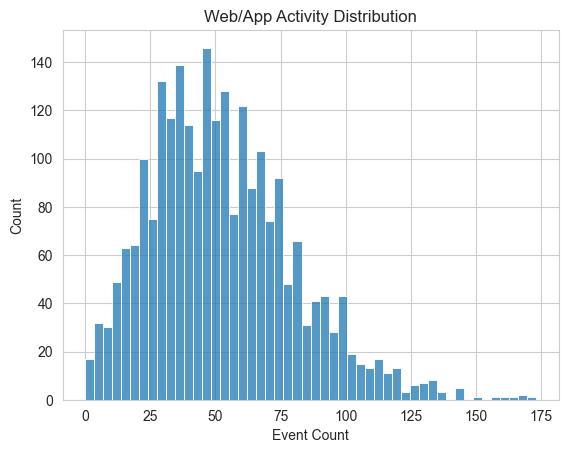

In [155]:
src = None
if 'web' in globals():
    src = globals()['web']
elif 'web_events' in globals():
    src = globals()['web_events']
elif 'datasets' in globals() and isinstance(datasets, dict):
    if datasets.get('web_events') is not None:
        src = datasets.get('web_events')
    elif datasets.get('web') is not None:
        src = datasets.get('web')
if src is None:
    raise NameError("No web events dataframe found (expected 'web' or 'web_events' or datasets['web_events']).")

if 'customer_id' not in src.columns:
    raise KeyError("web dataframe must contain 'customer_id' column")

# prefer summing numeric event columns per customer, fallback to group size
num_cols = src.select_dtypes(include='number').columns.tolist()
if len(num_cols) > 0:
    activity = src.groupby('customer_id')[num_cols].sum().sum(axis=1)
else:
    activity = src.groupby('customer_id').size()

sns.histplot(activity, bins=50)

plt.title("Web/App Activity Distribution")
plt.xlabel("Event Count")

plt.show()

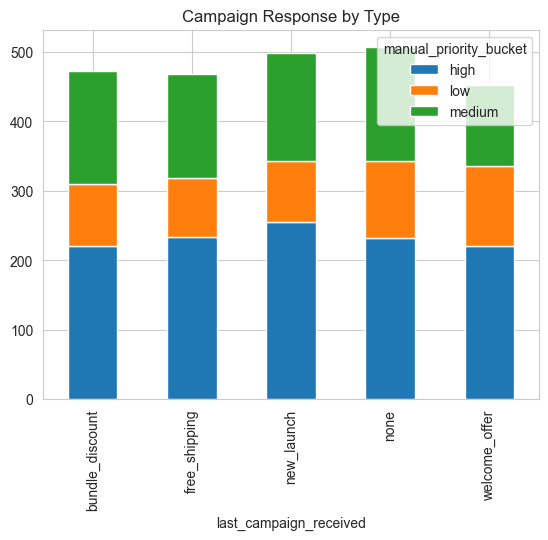

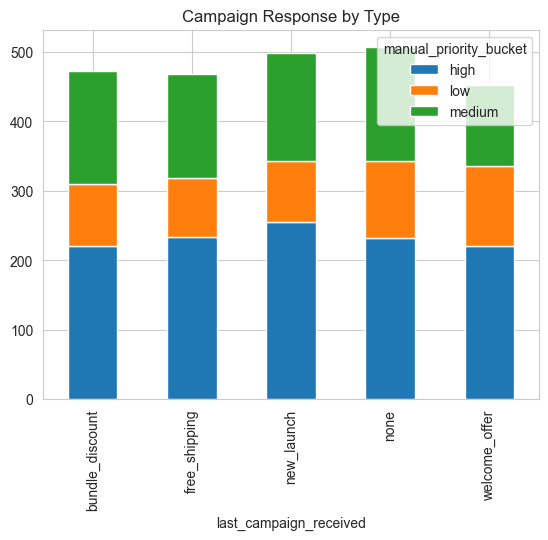

In [156]:
campaign_summary = pd.crosstab(
    interventions['last_campaign_received'],
    interventions['manual_priority_bucket']
)

campaign_summary.plot(kind='bar', stacked=True)

plt.title("Campaign Response by Type")

plt.show()

campaign_summary.plot(kind='bar', stacked=True)

plt.title("Campaign Response by Type")

plt.show()

Campaign Strategy:Medium and high campaign responses across all business campaigns are observed.This is indicative of consistent campaigns are needed as a business strategy for future too.